# Test completo di archivio, analisi e visualizzazione Sudoku

Questo notebook verifica l'intero flusso:

1. genera un nuovo Sudoku con soluzione unica;
2. lo salva nell'archivio;
3. lo ricarica dal file;
4. esegue l'analisi completa, che al primo accesso deve essere calcolata e salvata;
5. visualizza il risultato in tutti i modi disponibili;
6. richiede nuovamente la stessa analisi e verifica che venga restituita dalla cache in memoria.

Il notebook presuppone questi moduli nello stesso progetto:

- `sudoku_solver.py`
- `sudoku_archive.py`
- `sudoku_visualization.py`


In [2]:
import random
import time

import matplotlib.pyplot as plt
import pandas as pd

import sudoku_solver as ss
import sudoku_archive as sa
import sudoku_visualization as sv
import sudoku_generator as sg

plt.rcParams["figure.figsize"] = (7, 7)


## 1. Generazione di un nuovo Sudoku

Viene usato un seed casuale, così ogni esecuzione completa del notebook tende a produrre un Sudoku nuovo. In questo modo non dovrebbe esistere già un'analisi salvata per la stessa griglia.


Seed: 97776876
Nome: generated_97776876
Numero di indizi: 30


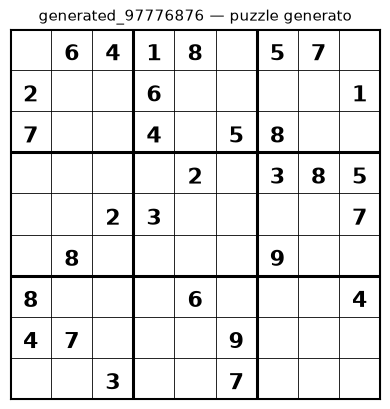

In [21]:
seed = random.SystemRandom().randrange(1, 10**9)
rng = random.Random(seed)

generated_puzzle, generated_solution = sg.generate_unique_puzzle(
    target_clues=30,
    rng=rng,
)

puzzle_name = f"generated_{seed}"

print("Seed:", seed)
print("Nome:", puzzle_name)
print("Numero di indizi:", int((generated_puzzle != 0).sum()))

sv.draw_grid(
    generated_puzzle,
    title=f"{puzzle_name} — puzzle generato",
)
plt.show()


## 3. Caricamento del Sudoku

Il Sudoku viene ricaricato usando il nome assegnato. La griglia caricata viene confrontata con quella generata.


Sudoku caricato
ID: 80e1dd00a1a3216cd7b6
Nome: coach_hell_0
Percorso: sudoku_data\puzzles\80e1dd00a1a3216cd7b6.json


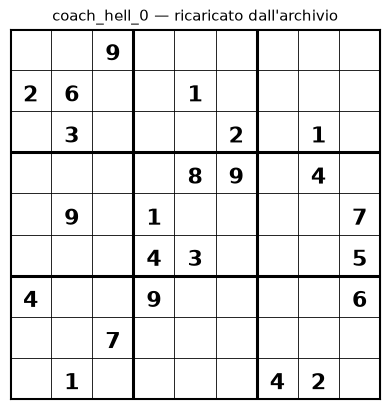

In [58]:
loaded_info = sa.load_sudoku('coach_hell_0')
loaded_puzzle = loaded_info["grid"]

print("Sudoku caricato")
print("ID:", loaded_info["id"])
print("Nome:", loaded_info["name"])
print("Percorso:", loaded_info["path"])

sv.draw_grid(
    loaded_puzzle,
    title=f"{loaded_info['name']} — ricaricato dall'archivio",
)
plt.show()


## 4. Prima analisi completa

Dato che il Sudoku è appena stato generato, la sua analisi non dovrebbe essere presente né nella cache in memoria né nell'archivio. La prima chiamata deve quindi:

1. eseguire il solver;
2. costruire la catena logica;
3. valutare la difficoltà;
4. salvare automaticamente l'analisi;
5. inserirla nella cache in memoria.


In [59]:
start = time.perf_counter()

first_result = sa.analyse_puzzle_cached(
    loaded_puzzle,
    name=loaded_info["name"],
)

first_elapsed = time.perf_counter() - start

print("Prima analisi completata")
print("Tempo:", round(first_elapsed, 4), "secondi")
print("Stato:", first_result["status"])
print("Valutazione:", first_result["grading"])
print("Numero di step:", len(first_result["chain"]))


Prima analisi completata
Tempo: 1.0446 secondi
Stato: stuck
Valutazione: {'label': 'Oltre la copertura del solver', 'max_difficulty': 2.0, 'max_level': 2, 'score': 2, 'workload_score': 2, 'histogram': {1: 8, 2: 2, 3: 0, 4: 0, 5: 0}, 'status': 'stuck', 'n_steps': 10, 'hardest_steps': 2, 'nontrivial_steps': 2, 'advanced_steps': 0}
Numero di step: 10


## 5. Visualizzazione della griglia risolta


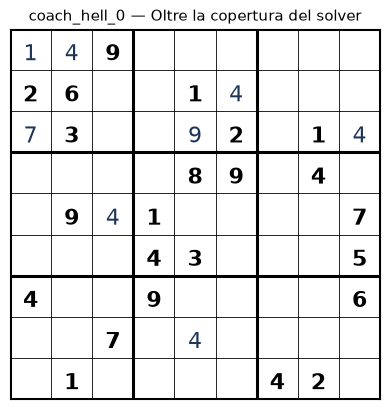

In [60]:
sv.draw_grid(
    first_result["solved_grid"],
    given_mask=(first_result["original"] != 0),
    title=(
        f"{first_result['name']} — "
        f"{first_result['grading']['label']}"
    ),
)
plt.show()


## 6. Catena di difficoltà

Mostra il livello di difficoltà usato a ogni step e il numero complessivo di passaggi per livello.


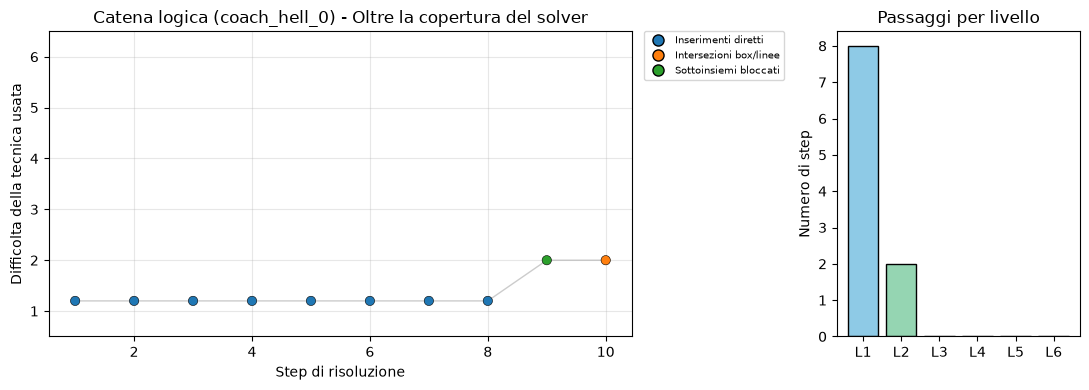

In [61]:
sv.plot_difficulty_chain(first_result)


## 7. Passaggio più difficile

Viene visualizzato lo stato della griglia in corrispondenza del passaggio con difficoltà massima.


Indice: 8
Step: 9
Tecnica: Naked Pair
Difficoltà: 2.0
Descrizione: Le celle R2C3, R3C3 contengono solo i candidati [5, 8]: eliminati dal resto del col.


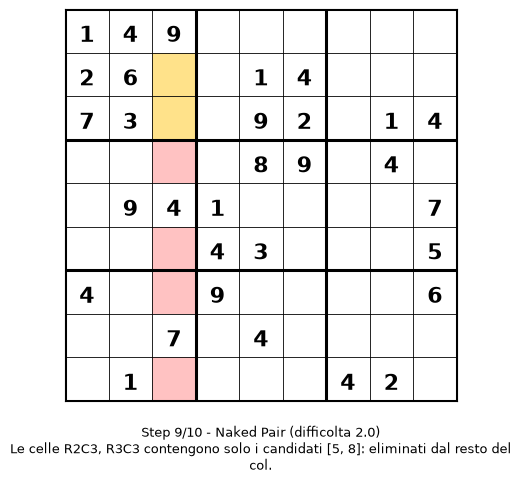

In [62]:
if first_result["chain"]:
    hardest_index = max(
        range(len(first_result["chain"])),
        key=lambda index: first_result["chain"][index]["difficulty"],
    )

    hardest_move = first_result["chain"][hardest_index]

    print("Indice:", hardest_index)
    print("Step:", hardest_move["step"])
    print("Tecnica:", hardest_move["technique"])
    print("Difficoltà:", hardest_move["difficulty"])
    print("Descrizione:", hardest_move["description"])

    sv.draw_step(first_result, hardest_index)
else:
    print("Nessun passaggio disponibile.")


## 8. Tabella completa della catena


In [55]:
chain_dataframe = sv.summary_dataframe(first_result)
chain_dataframe


,step,tecnica,famiglia,difficolta,n_alternative,descrizione
0,1,Naked Single,Inserimenti diretti,1.0,41,La cella R3C5 ha un solo candidato possibile: 1.
1,2,Naked Single,Inserimenti diretti,1.0,46,La cella R2C4 ha un solo candidato possibile: 9.
2,3,Naked Single,Inserimenti diretti,1.0,44,La cella R3C6 ha un solo candidato possibile: 8.
3,4,Naked Single,Inserimenti diretti,1.0,40,La cella R1C6 ha un solo candidato possibile: 2.
4,5,Naked Single,Inserimenti diretti,1.0,38,La cella R7C6 ha un solo candidato possibile: 6.
5,6,Naked Single,Inserimenti diretti,1.0,36,La cella R8C6 ha un solo candidato possibile: 1.
6,7,Naked Single,Inserimenti diretti,1.0,30,La cella R6C6 ha un solo candidato possibile: 3.
7,8,Naked Single,Inserimenti diretti,1.0,29,La cella R8C4 ha un solo candidato possibile: 7.
8,9,Naked Single,Inserimenti diretti,1.0,27,La cella R9C5 ha un solo candidato possibile: 4.
9,10,Naked Single,Inserimenti diretti,1.0,21,La cella R7C5 ha un solo candidato possibile: 5.


## 9. Frequenza delle tecniche effettivamente usate


In [56]:
technique_counts = (
    chain_dataframe["tecnica"]
    .value_counts()
    .rename_axis("tecnica")
    .reset_index(name="numero_step")
)

technique_counts


,tecnica,numero_step
0,Naked Single,40
1,Hidden Single,15
2,Two-String Kite,1
3,Y-Wing,1


## 10. Attività delle tecniche durante la risoluzione

Se `sudoku_visualization.py` contiene `plot_technique_activity`, viene mostrata la heatmap con:

- righe: tecniche;
- colonne: step;
- valori: numero di applicazioni disponibili in quello stato.

Le analisi devono contenere `applicable_by_technique` perché questa visualizzazione sia significativa.


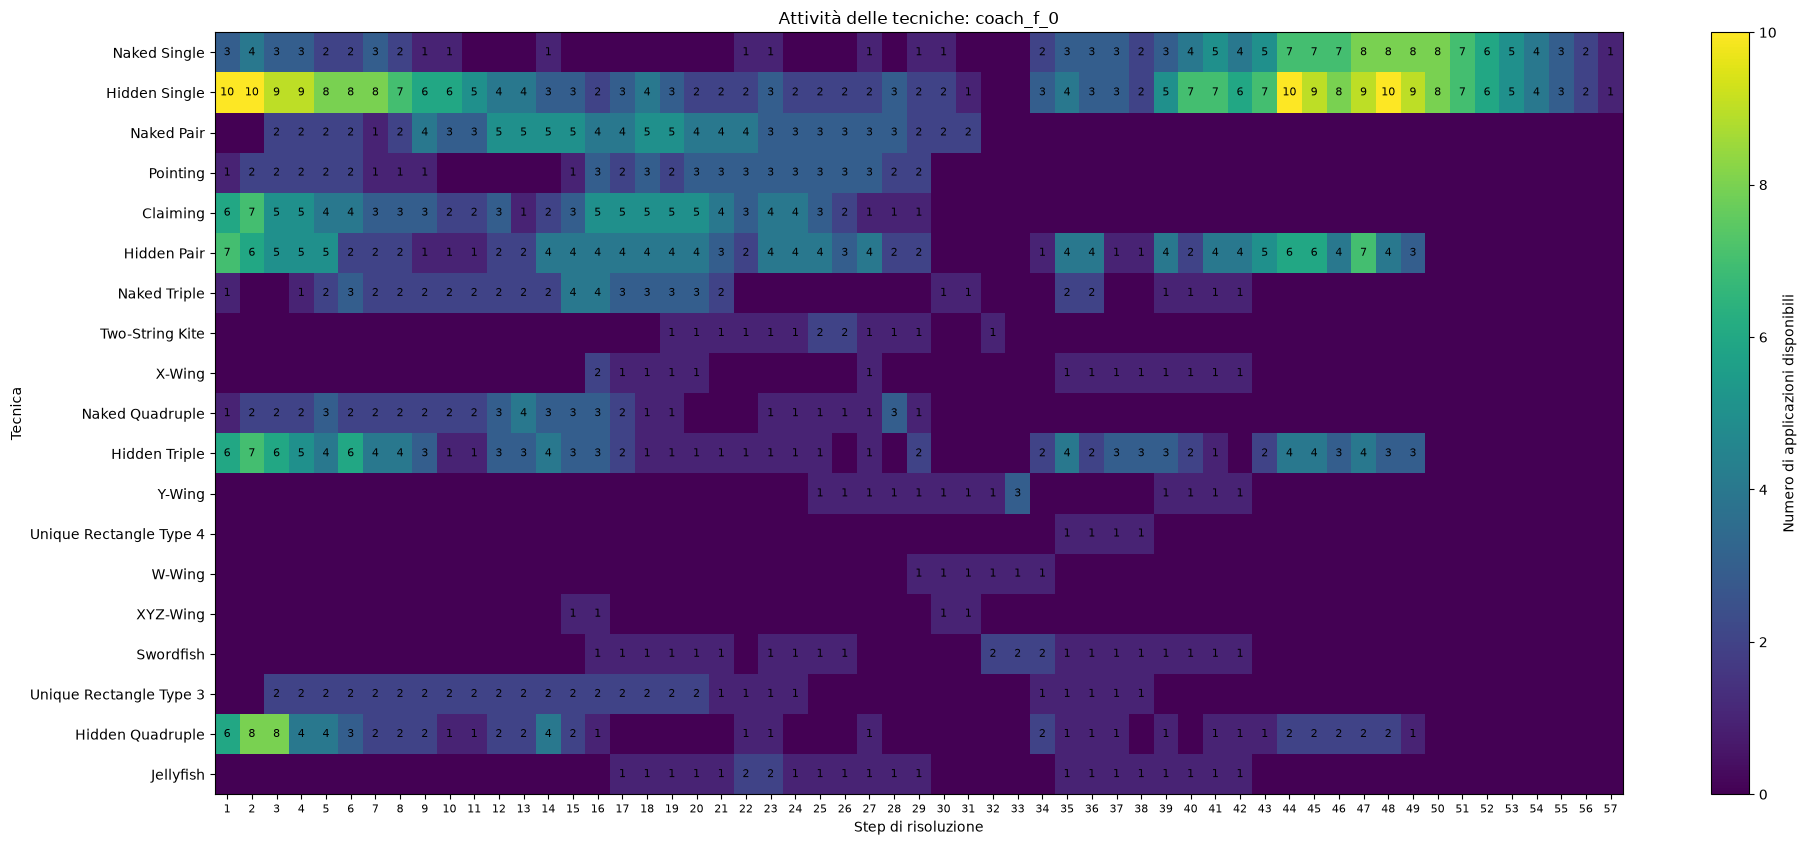

In [57]:
if hasattr(sv, "plot_technique_activity"):
    has_activity_data = any(
        "applicable_by_technique" in step
        for step in first_result["chain"]
    )

    if has_activity_data:
        sv.plot_technique_activity(first_result)
    else:
        print(
            "La funzione esiste, ma l'analisi non contiene "
            "'applicable_by_technique'. Aggiorna solve_and_log "
            "e incrementa ANALYSIS_VERSION."
        )
else:
    print(
        "plot_technique_activity non è presente in "
        "sudoku_visualization.py."
    )


## 11. Galleria

La galleria è pensata per più Sudoku, ma può essere usata anche con un solo risultato per verificare la vista riepilogativa.


In [3]:
sudoku_ref_list = sa.list_sudokus()
sudoku_list = [sa.load_sudoku(x['name']) for x in sudoku_ref_list]
sudoku_analysis_list = [sa.analyse_puzzle_cached(x['grid'], x['name']) for x in sudoku_list]

In [4]:
sudoku_analysis_list

[{'name': 'coach_0',
  'original': array([[0, 0, 0, 7, 5, 4, 0, 8, 0],
         [1, 4, 7, 6, 0, 0, 2, 9, 0],
         [0, 0, 5, 0, 2, 0, 0, 7, 0],
         [5, 2, 9, 3, 0, 7, 8, 6, 1],
         [7, 0, 8, 0, 0, 1, 4, 0, 3],
         [4, 0, 3, 0, 0, 5, 0, 2, 0],
         [8, 0, 0, 4, 0, 3, 5, 1, 0],
         [3, 7, 0, 0, 8, 0, 6, 0, 0],
         [0, 5, 4, 9, 1, 0, 7, 3, 8]]),
  'solved_grid': array([[9, 3, 2, 7, 5, 4, 1, 8, 6],
         [1, 4, 7, 6, 3, 8, 2, 9, 5],
         [6, 8, 5, 1, 2, 9, 3, 7, 4],
         [5, 2, 9, 3, 4, 7, 8, 6, 1],
         [7, 6, 8, 2, 9, 1, 4, 5, 3],
         [4, 1, 3, 8, 6, 5, 9, 2, 7],
         [8, 9, 6, 4, 7, 3, 5, 1, 2],
         [3, 7, 1, 5, 8, 2, 6, 4, 9],
         [2, 5, 4, 9, 1, 6, 7, 3, 8]]),
  'chain': [{'technique': 'Naked Single',
    'family': 'Inserimenti diretti',
    'difficulty': 1.0,
    'description': 'La cella R1C9 ha un solo candidato possibile: 6.',
    'placements': [(0, 8, 6)],
    'eliminations': [],
    'highlight': {'primary': [(0, 8)

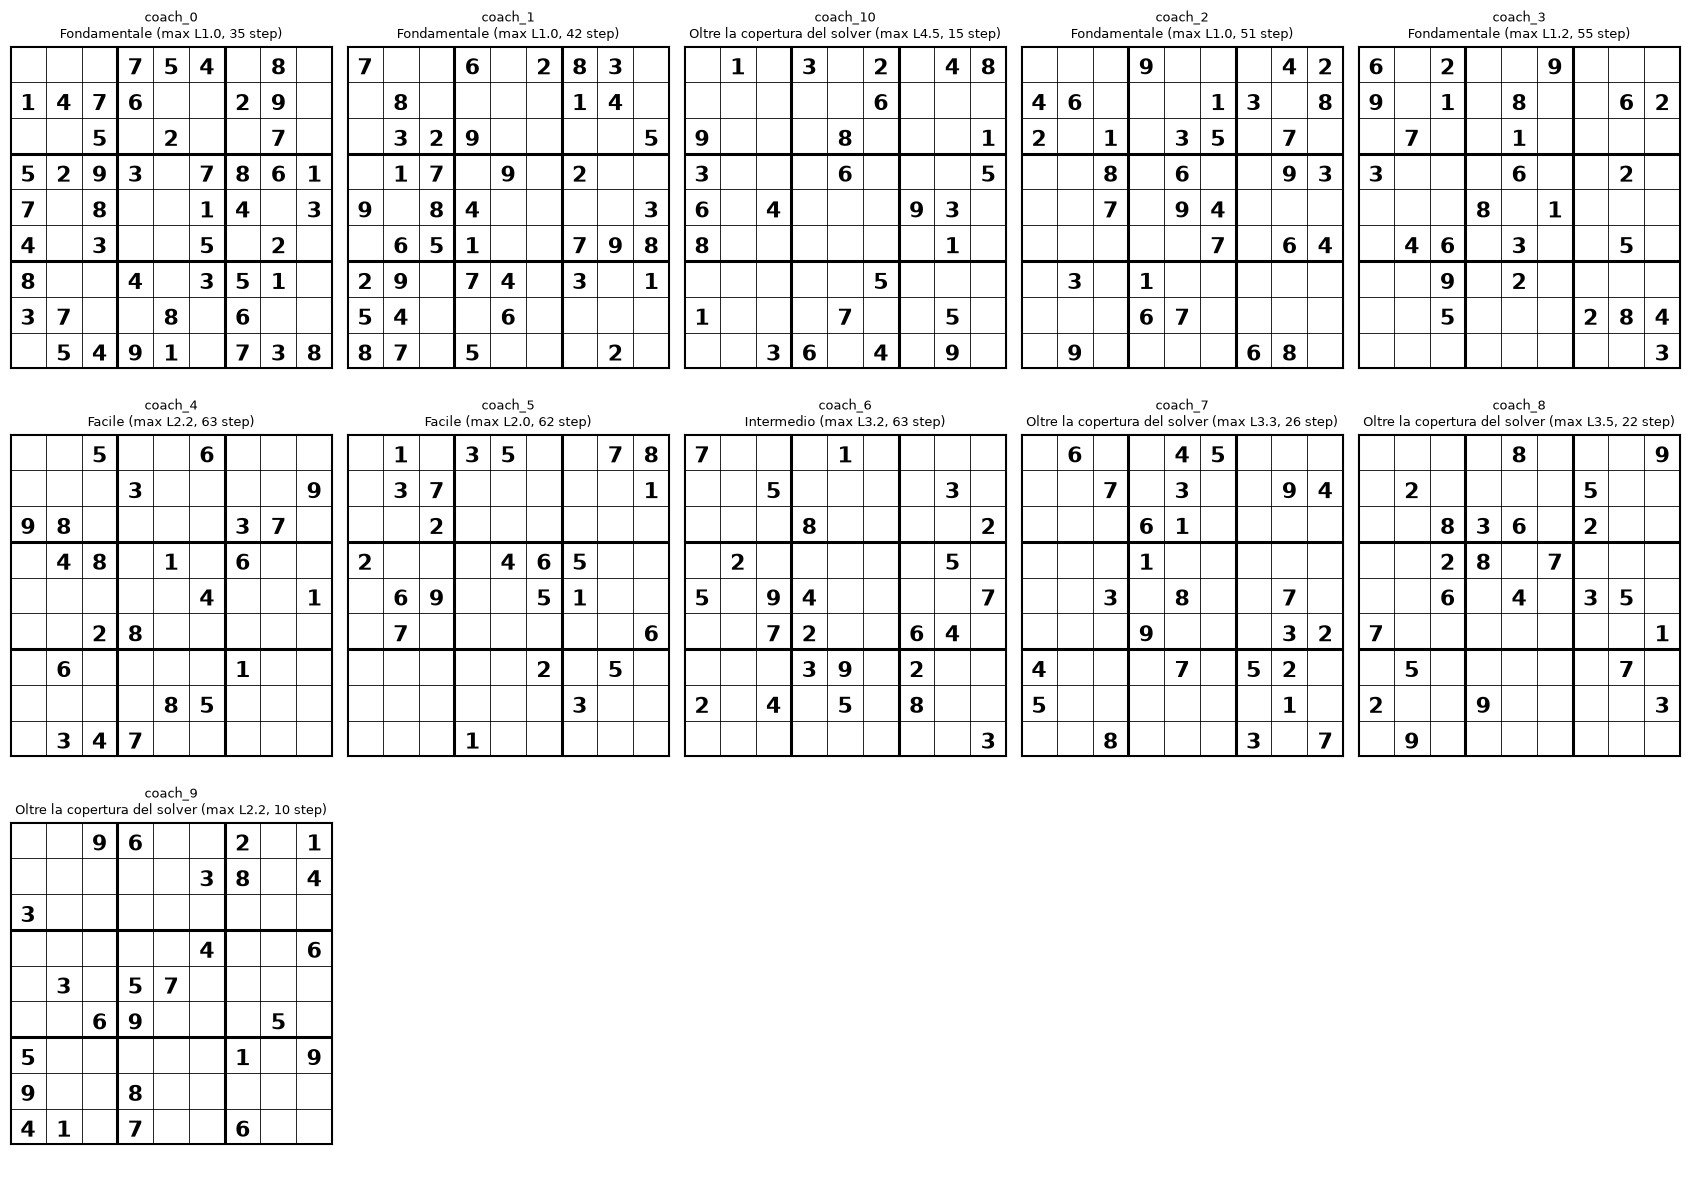

In [5]:
sv.gallery(sudoku_analysis_list, ncols=5)

## 12. Riepilogo sintetico


In [9]:
sv.analyses_summary_dataframe(sudoku_analysis_list).sort_values('difficolta_massima')

,nome,stato,difficolta,difficolta_massima,livello_massimo,punteggio,numero_step,step_massimi,step_non_banali,step_avanzati,solvibile_verificato
0,coach_0,solved,Fondamentale,1.0,1,0,35,35,0,0,None
1,coach_1,solved,Fondamentale,1.0,1,0,42,42,0,0,None
3,coach_2,solved,Fondamentale,1.0,1,0,51,51,0,0,None
4,coach_3,solved,Fondamentale,1.2,1,0,55,17,0,0,None
6,coach_5,solved,Facile,2.0,2,4,62,4,4,0,None
5,coach_4,solved,Facile,2.2,2,5,63,1,5,0,None
10,coach_9,stuck,Oltre la copertura del solver,2.2,2,3,10,1,3,0,True
7,coach_6,solved,Intermedio,3.2,3,10,63,1,6,0,None
8,coach_7,stuck,Oltre la copertura del solver,3.3,3,4,26,1,2,0,True
9,coach_8,stuck,Oltre la copertura del solver,3.5,3,19,22,1,7,0,True


## 14. Controllo dell'archivio

Mostra l'elenco dei Sudoku salvati e verifica che quello appena creato risulti analizzato.


In [10]:
archive_dataframe = pd.DataFrame(sa.list_sudokus())
archive_dataframe


,id,name,clues,analysed,updated_at
0,bb789ac37fa24651e428,coach_0,46,True,2026-07-16T11:17:54.034795+00:00
1,fd553e4d4cb903f41838,coach_1,39,True,2026-07-16T11:17:54.047797+00:00
2,4173f0f3cc7913dbbf50,coach_10,26,True,2026-07-16T11:17:54.059797+00:00
3,0ee36995ddef57d323e5,coach_2,30,True,2026-07-16T11:17:54.072800+00:00
4,cc8c83879169ae9641c1,coach_3,26,True,2026-07-16T11:17:54.083826+00:00
5,228c6972ee4bf2e779ef,coach_4,23,True,2026-07-16T11:17:54.094800+00:00
6,cefe060c064e2b69a77e,coach_5,23,True,2026-07-16T11:17:54.107799+00:00
7,93756c2b70e379569b33,coach_6,24,True,2026-07-16T11:17:54.119797+00:00
8,d8a276eb7add502b3e4f,coach_7,25,True,2026-07-16T11:17:54.133798+00:00
9,abeb720465b2621ff52a,coach_8,23,True,2026-07-16T11:17:54.145813+00:00
